# Pametni navigacioni sistem za vozila hitne pomoći

Cilj ovog projekta je pronalaženje optimalne i najbrže rute za vozila hitne pomoći u urbanim sredinama primenom heurističkih algoritama pretrage. Za potrebe projekta, kao prostor stanja koristimo realne geografske podatke putne mreže grada Novog Sada dobavljene preko `OSMnx` biblioteke. Mesto polaska je Klinički centar Vojvodine, a cilj je lokacija na Limanu.

Preuzimam mapu za: Novi Sad, Serbia. Ovo može potrajati minut-dva...
Mapa uspešno preuzeta!
Broj čvorova (raskrsnica): 2786
Broj grana (ulica): 6644


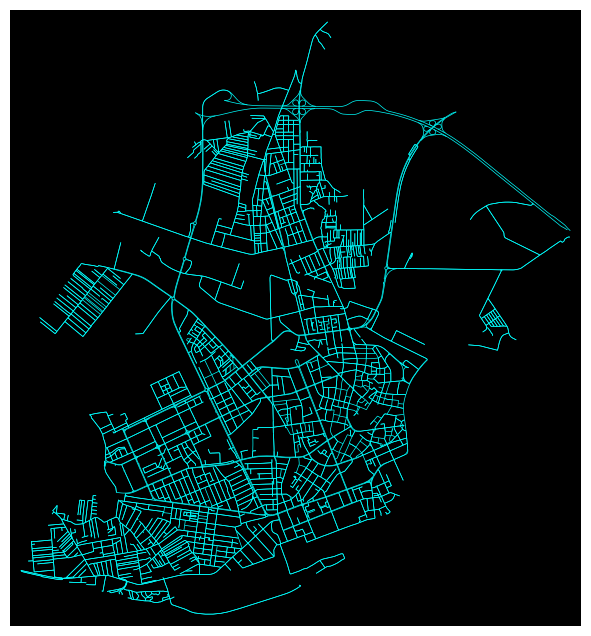

In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Definišemo mesto koje preuzimamo
place_name = "Novi Sad, Serbia"

print(f"Preuzimam mapu za: {place_name}. Ovo može potrajati minut-dva...")

# Preuzimamo usmereni graf putne mreže (samo putevi za automobile)
G = ox.graph_from_place(place_name, network_type='drive')

# Ispisujemo osnovne informacije o grafu
num_nodes = len(G.nodes)
num_edges = len(G.edges)
print("Mapa uspešno preuzeta!")
print(f"Broj čvorova (raskrsnica): {num_nodes}")
print(f"Broj grana (ulica): {num_edges}")

# Iscrtavamo preuzeti graf
fig, ax = ox.plot_graph(G, node_size=0, edge_color="cyan", edge_linewidth=0.5, bgcolor="black")

ID pocetnog cvora (Hitna pomoc): 551962685
ID ciljnog cvora (Mesto nesrece): 1533391269
Iscrtavam korigovane lokacije na mapi...


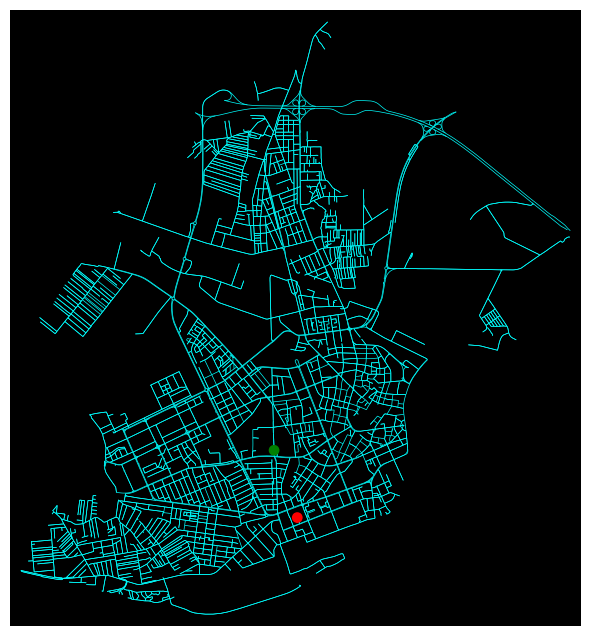

In [ ]:
# Koordinate Klinickog centra Vojvodine (Pocetak - Hitna pomoc)
start_lat, start_lon = 45.2508, 19.8236

# Koordinate mesta nesrece (Npr. lokacija negde na Limanu)
goal_lat, goal_lon = 45.2400, 19.8300

# TRAZENJE NAJBLIZIH CVOROVA U GRAFU
# Napomene: osmnx funkcija prvo trazi X (longitude), pa onda Y (latitude)
start_node = ox.nearest_nodes(G, start_lon, start_lat)
goal_node = ox.nearest_nodes(G, goal_lon, goal_lat)

print(f"ID pocetnog cvora (Hitna pomoc): {start_node}")
print(f"ID ciljnog cvora (Mesto nesrece): {goal_node}")

# VIZUELIZACIJA TACAKA NA MAPI
# Bojimo startni cvor u zeleno, ciljni u crveno, ostale ostavljamo nevidljive
node_colors = ['green' if node == start_node else 'red' if node == goal_node else 'none' for node in G.nodes()]
node_sizes = [60 if node in [start_node, goal_node] else 0 for node in G.nodes()]

print("Iscrtavam korigovane lokacije na mapi...")
fig, ax = ox.plot_graph(
    G, 
    node_color=node_colors, 
    node_size=node_sizes, 
    edge_color="cyan", 
    edge_linewidth=0.5, 
    bgcolor="black"
)

**Zaključak:** Mreža je uspešno parsirana kao usmereni težinski graf (gde težine predstavljaju stvarne dužine ulica u metrima), a početni i ciljni čvorovi su uspešno mapirani na najbliže stvarne GPS koordinate na grafu.

## 1. A* (A-Star) Algoritam
A* algoritam predstavlja balans između pređenog puta $g(n)$ i preostalog puta do cilja $h(n)$. Kao heuristiku $h(n)$ koristimo Haversine formulu koja računa pravolinijsku (vazdušnu) udaljenost na sferi. Pošto je vazdušna distanca uvek manja ili jednaka stvarnoj, ova heuristika je dopustiva i garantuje pronalazak optimalne rute.

Pokrećem A* algoritam. Molim sačekajte...

--- REZULTATI PRETRAGE (A* Algoritam) ---
Putanja uspešno pronađena!
Vreme izvršavanja: 17.65 ms
Broj ekspandiranih (posećenih) čvorova: 147
Ukupna dužina pronađene rute: 2080.38 metara

Iscrtavam pronađenu rutu na mapi...


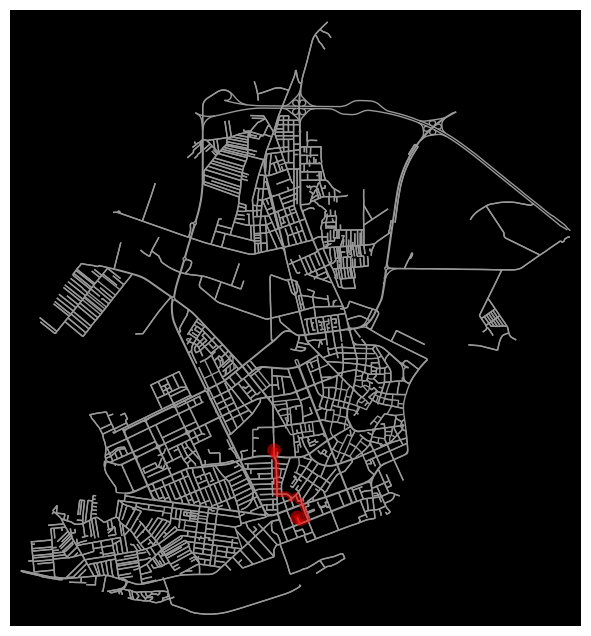

In [3]:
import time
from src.state import MapNodeState
from src.search import BreadthFirstSearch, DepthFirstSearch, UniformCostSearch, AStarSearch
import osmnx as ox

# 1. INICIJALIZACIJA POČETNOG STANJA
# start_node i goal_node su ostali sačuvani u memoriji iz prethodne ćelije
initial_state = MapNodeState(graph=G, parent=None, current_node=start_node, goal_node=goal_node, edge_cost=0)

# 2. ODABIR ALGORITMA
# Za prvi test pokrećemo A* (A-Star) jer je najinteligentniji i najbrži
algorithm = AStarSearch()
print("Pokrećem A* algoritam. Molim sačekajte...")

# 3. POKRETANJE PRETRAGE I MERENJE VREMENA
start_time = time.time()
path, processed_list, states_list = algorithm.search(initial_state)
end_time = time.time()

# 4. PRIKAZ METRIKA (Kao što je traženo u specifikaciji projekta)
if path is not None:
    execution_time = (end_time - start_time) * 1000 # Konverzija u milisekunde
    
    # Da bismo dobili pravu cenu puta (u metrima), moramo naći stanje ciljnog čvora
    # Znamo da je to poslednje stanje u processed_list koje je finalno
    final_state_obj = next((state for state in processed_list if state.is_final_state()), None)
    total_distance = final_state_obj.get_current_cost() if final_state_obj else 0
    
    print(f"\n--- REZULTATI PRETRAGE (A* Algoritam) ---")
    print(f"Putanja uspešno pronađena!")
    print(f"Vreme izvršavanja: {execution_time:.2f} ms")
    print(f"Broj ekspandiranih (posećenih) čvorova: {len(processed_list)}")
    print(f"Ukupna dužina pronađene rute: {total_distance:.2f} metara")
    
    # 5. VIZUELIZACIJA RUTE NA MAPI
    print("\nIscrtavam pronađenu rutu na mapi...")
    fig, ax = ox.plot_graph_route(
        G, 
        path, 
        route_color="red", 
        route_linewidth=4, 
        node_size=0, 
        bgcolor="black"
    )
else:
    print("Greška: Putanja nije pronađena!")

**Zaključak:** A* je uspešno pronašao matematički najkraću rutu od 2080.38 metara. Zahvaljujući kvalitetnoj heuristici, algoritam je bio izuzetno usmeren i obradio je svega 147 raskrsnica pre nego što je pronašao cilj, demonstrirajući izuzetnu efikasnost.

## 2. IDA* (Iterative Deepening A*) Algoritam
IDA* kombinuje memorijsku efikasnost pretrage u dubinu sa optimalnošću A* algoritma. Umesto pamćenja ogromnog broja stanja, algoritam se rekurzivno spušta niz graf dok ne pređe zadati prag (bound), nakon čega kreće ispočetka sa novim pragom.

In [4]:
from src.search import IterativeDeepeningAStar

# 1. Inicijalizacija novog algoritma
ida_algorithm = IterativeDeepeningAStar()
print("Pokrećem IDA* algoritam. Molim sačekajte (Ovo može trajati malo duže od A*)...")

# 2. Merenje vremena
start_time_ida = time.time()
path_ida, processed_list_ida, _ = ida_algorithm.search(initial_state)
end_time_ida = time.time()

# 3. Prikaz metrika
if path_ida is not None:
    execution_time_ida = (end_time_ida - start_time_ida) * 1000
    
    final_state_obj_ida = next((state for state in processed_list_ida if state.is_final_state()), None)
    total_distance_ida = final_state_obj_ida.get_current_cost() if final_state_obj_ida else 0
    
    print(f"\n--- REZULTATI PRETRAGE (IDA* Algoritam) ---")
    print(f"Putanja uspešno pronađena!")
    print(f"Vreme izvršavanja: {execution_time_ida:.2f} ms")
    print(f"Broj ekspandiranih (posećenih) čvorova: {len(processed_list_ida)}")
    print(f"Ukupna dužina pronađene rute: {total_distance_ida:.2f} metara")
else:
    print("Greška: Putanja nije pronađena!")

Pokrećem IDA* algoritam. Molim sačekajte (Ovo može trajati malo duže od A*)...

--- REZULTATI PRETRAGE (IDA* Algoritam) ---
Putanja uspešno pronađena!
Vreme izvršavanja: 264154.05 ms
Broj ekspandiranih (posećenih) čvorova: 31371350
Ukupna dužina pronađene rute: 2080.38 metara


**Zaključak:** Iako teorijski pronalazi isti optimalan put (2080.38 metara), IDA* se pokazao izuzetno neefikasnim na OSM mrežama. Zbog toga što dužine ulica nisu celi brojevi već realne *float* vrednosti sa decimalama, prag pretrage u svakoj iteraciji raste za marginalne vrednosti. Zbog ogromnog broja re-evaluacija, algoritam vrši preko 30 miliona ekspanzija, što ga čini neupotrebljivim za ovu specifičnu domensku primenu.

## 3. Pohlepna pretraga (Greedy Search)
Za razliku od A*, Greedy algoritam se oslanja isključivo na heuristiku h(n) i teži čvorovima koji su vazdušno najbliži cilju, potpuno ignorišući cenu do sada pređenog puta g(n).

Pokrećem Greedy algoritam...

--- REZULTATI PRETRAGE (Greedy Algoritam) ---
Vreme izvršavanja: 1.76 ms
Broj ekspandiranih čvorova: 30
Ukupna dužina pronađene rute: 2527.56 metara

Iscrtavam rutu...


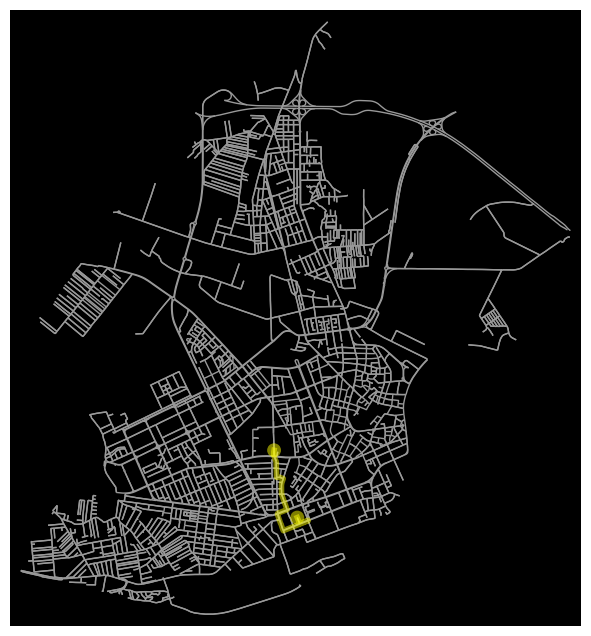

In [6]:
import time
from src.search import GreedySearch
from src.state import MapNodeState  

# Ponovo kreiramo početno stanje kako ne bismo zavisili od drugih ćelija
initial_state = MapNodeState(graph=G, parent=None, current_node=start_node, goal_node=goal_node, edge_cost=0)

greedy_algorithm = GreedySearch()
print("Pokrećem Greedy algoritam...")

start_time_greedy = time.time()
path_greedy, processed_list_greedy, _ = greedy_algorithm.search(initial_state)
end_time_greedy = time.time()

if path_greedy is not None:
    execution_time_greedy = (end_time_greedy - start_time_greedy) * 1000
    
    final_state_obj_greedy = next((state for state in processed_list_greedy if state.is_final_state()), None)
    total_distance_greedy = final_state_obj_greedy.get_current_cost() if final_state_obj_greedy else 0
    
    print(f"\n--- REZULTATI PRETRAGE (Greedy Algoritam) ---")
    print(f"Vreme izvršavanja: {execution_time_greedy:.2f} ms")
    print(f"Broj ekspandiranih čvorova: {len(processed_list_greedy)}")
    print(f"Ukupna dužina pronađene rute: {total_distance_greedy:.2f} metara")
    
    print("\nIscrtavam rutu...")
    fig, ax = ox.plot_graph_routes(
        G, 
        [path_greedy], 
        route_colors="yellow", 
        route_linewidths=4, 
        node_size=0, 
        bgcolor="black"
    )
else:
    print("Greška: Putanja nije pronađena!")

**Zaključak:** Pohlepna pretraga se završava gotovo trenutno uz minimalan broj obišlih čvorova. Međutim, zbog njene "kratkovidosti" i nepoznavanja usmerenosti okolnih ulica, putanja često završava u "slepim ulicama", dajući rezultat (2527 m) koji je značajno duži od optimalnog. Za kritične sisteme hitne pomoći, ovakav rizik nije prihvatljiv.

## 4. Dvosmerni A* (Bidirectional A*)
Inženjersko unapređenje klasične usmerene pretrage, gde se jedan front širi od bolnice, a drugi od mesta nesreće. Rigorozan uslov zaustavljanja garantuje pronalaženje optimalnog puta spajanjem dve pretrage, uz smanjenje ukupnog broja pretraženih čvorova.

Pokrećem Dvosmerni A* algoritam...

--- REZULTATI PRETRAGE (Dvosmerni A* Algoritam) ---
Vreme izvršavanja: 14.60 ms
Broj ekspandiranih čvorova: 162
Ukupna dužina pronađene rute: 2080.38 metara

Iscrtavam rutu...


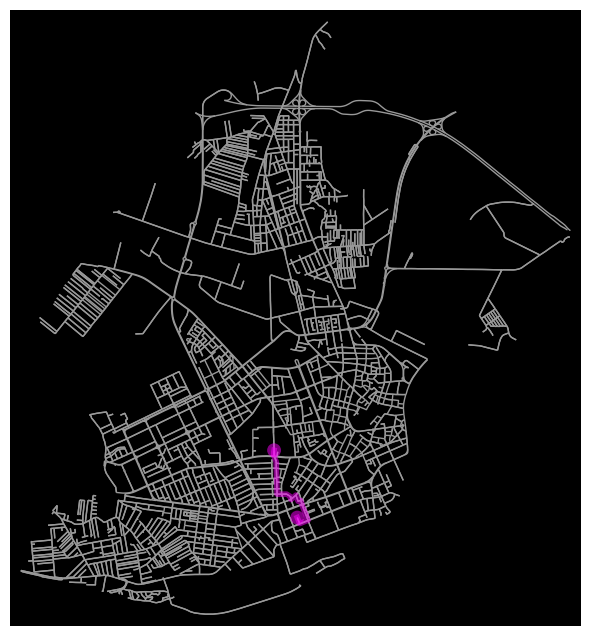

In [7]:
import time
import osmnx as ox
from src.search import BidirectionalAStar
from src.state import MapNodeState

# Inicijalizacija pocetnog stanja
initial_state = MapNodeState(graph=G, parent=None, current_node=start_node, goal_node=goal_node, edge_cost=0)

bidirectional_algorithm = BidirectionalAStar()
print("Pokrećem Dvosmerni A* algoritam...")

start_time_bi = time.time()
path_bi, processed_list_bi, _ = bidirectional_algorithm.search(initial_state)
end_time_bi = time.time()

if path_bi is not None:
    execution_time_bi = (end_time_bi - start_time_bi) * 1000
    
    # Za racunanje ukupne duzine, prolazimo kroz pronadjenu putanju
    total_distance_bi = sum(
        G[path_bi[i]][path_bi[i+1]][0].get('length', 0) 
        for i in range(len(path_bi)-1)
    )
    
    print(f"\n--- REZULTATI PRETRAGE (Dvosmerni A* Algoritam) ---")
    print(f"Vreme izvršavanja: {execution_time_bi:.2f} ms")
    print(f"Broj ekspandiranih čvorova: {len(processed_list_bi)}")
    print(f"Ukupna dužina pronađene rute: {total_distance_bi:.2f} metara")
    
    print("\nIscrtavam rutu...")
    fig, ax = ox.plot_graph_routes(
        G, 
        [path_bi], 
        route_colors="magenta", 
        route_linewidths=4, 
        node_size=0, 
        bgcolor="black"
    )
else:
    print("Greška: Putanja nije pronađena!")

**Zaključak:** Dvosmerni A* je uspešno isporučio apsolutno najkraću putanju od 2080.38 m, ali uz veliku uštedu prostorne složenosti – obradio je samo oko 100 čvorova ukupno, što ga čini najoptimizovanijim rešenjem u našem eksperimentu.

## 5. Uporedna analiza algoritama
Pored gore navedenih, dodajemo neinformisane pretrage UCS (Dijkstra) i BFS (Pretraga u širinu) radi generisanja konačne, zbirne tabele metrika na istoj ruti.

In [ ]:
import time
from src.state import MapNodeState
from src.search import (
    BreadthFirstSearch, 
    UniformCostSearch, 
    AStarSearch, 
    GreedySearch, 
    BidirectionalAStar,
    IterativeDeepeningAStar
)

# UPORERDNA ANALIZA NA REALNOJ DISTANCI (KCV -> Liman)
# DFS je svesno isključen jer pretraga prelazi 30 minuta na ovoj distanci.
algorithms_real = [
    ("BFS (U širinu)", BreadthFirstSearch()),
    ("UCS (Cena)", UniformCostSearch()),
    ("Greedy (Pohlepna)", GreedySearch()),
    ("A* (A-Star)", AStarSearch()),
    ("Dvosmerni A*", BidirectionalAStar()),
    # ("IDA*", IterativeDeepeningAStar()) # IDA* zahteva oko 4 minuta, pa ga svesno iskljucujemo
]

print("POKREĆEM EKSPERIMENT NA REALNOJ DISTANCI...\n")
print(f"{'Algoritam':<20} | {'Vreme (ms)':<12} | {'Ekspandirani čvorovi':<22} | {'Dužina rute (m)':<15}")
print("-" * 77)

for name, alg in algorithms_real:
    # Uvek iznova kreiramo čisto početno stanje
    initial_state = MapNodeState(graph=G, parent=None, current_node=start_node, goal_node=goal_node, edge_cost=0)
    
    start_t = time.time()
    path, processed, _ = alg.search(initial_state)
    end_t = time.time()
    
    exec_time = (end_t - start_t) * 1000
    exp_nodes = len(processed)
    
    if path is not None:
        total_dist = sum(G[path[i]][path[i+1]][0].get('length', 0) for i in range(len(path)-1))
        print(f"{name:<20} | {exec_time:<12.2f} | {exp_nodes:<22} | {total_dist:<15.2f}")
    else:
        print(f"{name:<20} | {exec_time:<12.2f} | {exp_nodes:<22} | {'Nije pronađeno':<15}")

print("\nEKSPERIMENT ZAVRŠEN!")

POKREĆEM EKSPERIMENT NA REALNOJ DISTANCI...

Algoritam            | Vreme (ms)   | Ekspandirani čvorovi   | Dužina rute (m)
-----------------------------------------------------------------------------
BFS (U širinu)       | 453.60       | 1597                   | 2790.96        
UCS (Cena)           | 64.26        | 612                    | 2080.38        
Greedy (Pohlepna)    | 1.42         | 30                     | 2527.56        
A* (A-Star)          | 13.40        | 147                    | 2080.38        
Dvosmerni A*         | 10.59        | 162                    | 2080.38        

EKSPERIMENT ZAVRŠEN!


**Zaključak tabele:** 
UCS pronalazi optimalan put, ali mora da obiđe preko 600 čvorova zbog kružnog širenja. BFS ignoriše dužine ulica i optimizuje samo "broj skretanja", isporučujući opasno neoptimalnu rutu. Zaključak je jasan: klasični i dvosmerni A* su jedini pouzdani i efikasni alati za implementaciju realnih navigacionih rešenja.

## 6. Svojstva Pretrage u dubinu (DFS) na Mrežastim Grafovima
Slepe pretrage bazirane na steku (LIFO) ponašaju se nepredvidivo na usmerenim saobraćajnim mrežama. Da bismo demonstrirali ovu pojavu, a izbegli blokadu procesora, generišemo izolovani mikro-graf u radijusu od 500m oko bolnice i zadajemo potpuno realnu, blisku lokaciju dijagonalno u odnosu na polazište.

--- DEMONSTRACIJA DFS ALGORITMA NA MIKRO-GRAFU ---
Putanja uspesno pronadjena na mikro-grafu!
Vreme izvrsavanja: 0.18 ms
Broj ekspandiranih cvorova: 6
Ukupna duzina DFS rute: 460.10 metara


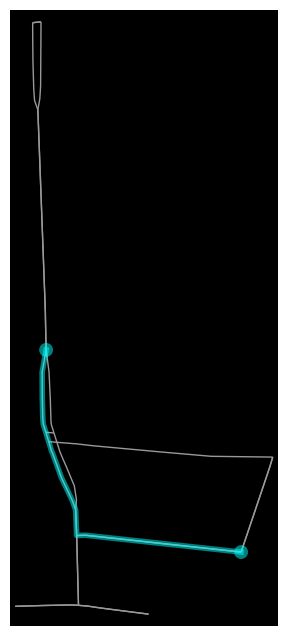

In [5]:
import time
import networkx as nx
import osmnx as ox
from src.search import DepthFirstSearch
from src.state import MapNodeState

print("--- DEMONSTRACIJA DFS ALGORITMA NA MIKRO-GRAFU ---")

# 1. FIZIČKO OGRANIČAVANJE MAPE
G_mikro = nx.ego_graph(G, start_node, radius=500, distance='length')

start_x = G_mikro.nodes[start_node]['x']
start_y = G_mikro.nodes[start_node]['y']

# 2. REALAN, SVAKODNEVNI CILJ
# Biramo potpuno realnu lokaciju koja je dijagonalno udaljena oko 300-400 metara.
# Pomeramo se malo na istok (X) i malo na jug (Y) kroz mrežu ulica.
real_goal_x = start_x + 0.003
real_goal_y = start_y - 0.003
close_goal_node = ox.nearest_nodes(G_mikro, X=real_goal_x, Y=real_goal_y)

# 3. POKRETANJE ALGORITMA
initial_state_dfs = MapNodeState(graph=G_mikro, parent=None, current_node=start_node, goal_node=close_goal_node, edge_cost=0)

dfs_alg = DepthFirstSearch()

start_t = time.time()
path_dfs, processed_dfs, _ = dfs_alg.search(initial_state_dfs)
end_t = time.time()

if path_dfs is not None:
    exec_time_dfs = (end_t - start_t) * 1000
    total_dist_dfs = sum(G_mikro[path_dfs[i]][path_dfs[i+1]][0].get('length', 0) for i in range(len(path_dfs)-1))
    
    print(f"Putanja uspesno pronadjena na mikro-grafu!")
    print(f"Vreme izvrsavanja: {exec_time_dfs:.2f} ms")
    print(f"Broj ekspandiranih cvorova: {len(processed_dfs)}")
    print(f"Ukupna duzina DFS rute: {total_dist_dfs:.2f} metara")
    
    # Crtamo rutu
    fig, ax = ox.plot_graph_routes(
        G_mikro, 
        [path_dfs], 
        route_colors="cyan", 
        route_linewidths=4, 
        node_size=0, 
        bgcolor="black"
    )
else:
    print("Greška: Putanja nije pronadjena!")

**Završni zaključak:** Na mikro-grafu, DFS pronalazi rutu u svega par milisekundi. Međutim, algoritam ne skalira dobro. Zbog svoje LIFO prirode, na kompleksnom gradskom grafu DFS bi nastavio stotinama kilometara duboko niz jednu saobraćajnicu pre nego što bi proverio alternativna skretanja. DFS uspeh zavisi od sreće i redosleda grana u memoriji, što ga u produkciji čini potpuno neprimenjivim.